<a href="https://colab.research.google.com/github/Sunidhi-Gautam/FL_Implementation/blob/main/Teacher_Side_KD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sunidhigautam26","key":"df9c2dd0e0f5995bb0a2fd692c71ec16"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [19]:
import os
import random
import shutil
import numpy as np
import torch
import timm
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import json

from sklearn.metrics import classification_report
from tqdm import tqdm
from collections import Counter
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
RAW_DATASETS_DIR = "/content/raw_teacher_datasets"
os.makedirs(RAW_DATASETS_DIR, exist_ok=True)

print("Raw datasets will be stored in:", RAW_DATASETS_DIR)

Raw datasets will be stored in: /content/raw_teacher_datasets


**Dataset Downloads For Teacher Model**

In [6]:
print("Downloading Dataset 1: Tomato Village (GitHub)")

!git clone https://github.com/mamta-joshi-gehlot/Tomato-Village.git /content/tmp_tomato_village

shutil.move(
    "/content/tmp_tomato_village",
    os.path.join(RAW_DATASETS_DIR, "dataset_1_tomato_village")
)

print("Dataset 1 ready\n")

Cloning into '/content/tmp_tomato_village'...
remote: Enumerating objects: 45041, done.
remote: Counting objects: 100% (26934/26934), done.
remote: Compressing objects: 100% (15220/15220), done.
remote: Total 45041 (delta 11469), reused 26919 (delta 11462), pack-reused 18107 (from 1)
Receiving objects: 100% (45041/45041), 3.15 GiB | 31.97 MiB/s, done.
Resolving deltas: 100% (14334/14334), done.
Updating files: 100% (53289/53289), done.
Dataset 1 ready



In [7]:
import zipfile

print("Downloading Dataset 2: Tomato Leaf (Kaggle)")

!kaggle datasets download -d kaustubhb999/tomatoleaf -p /content

zip_path = "/content/tomatoleaf.zip"
extract_path = "/content/tmp_tomatoleaf"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

shutil.move(
    extract_path,
    os.path.join(RAW_DATASETS_DIR, "dataset_2_tomatoleaf")
)

print("Dataset 2 ready\n")

Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
 73% 131M/179M [00:00<00:00, 1.13GB/s]
100% 179M/179M [00:00<00:00, 375MB/s] 
Dataset 2 ready



In [8]:
print("Downloading Dataset 3: Tomato (Kaggle - Ashish Motwani)")

!kaggle datasets download -d ashishmotwani/tomato -p /content

zip_path = "/content/tomato.zip"
extract_path = "/content/tmp_tomato_3"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

shutil.move(
    extract_path,
    os.path.join(RAW_DATASETS_DIR, "dataset_3_tomato")
)

print("Dataset 3 ready\n")

Dataset URL: https://www.kaggle.com/datasets/ashishmotwani/tomato
License(s): copyright-authors
 97% 1.32G/1.37G [00:12<00:01, 39.8MB/s]
100% 1.37G/1.37G [00:13<00:00, 112MB/s] 
Dataset 3 ready



In [9]:
print("Downloading Dataset 4: Tomato Diseases (Kaggle)")

!kaggle datasets download -d luisolazo/tomato-diseases -p /content

zip_path = "/content/tomato-diseases.zip"
extract_path = "/content/tmp_tomato_diseases"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

shutil.move(
    extract_path,
    os.path.join(RAW_DATASETS_DIR, "dataset_4_tomato_diseases")
)

print("Dataset 4 ready\n")

Dataset URL: https://www.kaggle.com/datasets/luisolazo/tomato-diseases
License(s): CC0-1.0
 89% 367M/411M [00:00<00:00, 395MB/s]
100% 411M/411M [00:01<00:00, 387MB/s]
Dataset 4 ready



**Verify Downloads**

In [10]:
print("\nFinal raw datasets available:\n")

for d in sorted(os.listdir(RAW_DATASETS_DIR)):
    print("•", d)


Final raw datasets available:

• dataset_1_tomato_village
• dataset_2_tomatoleaf
• dataset_3_tomato
• dataset_4_tomato_diseases


**Canonical Class Map**

In [11]:
CLASS_MAP = {
    # Early blight
    "early_blight": "early_blight",
    "Early_blight": "early_blight",
    "Early Blight": "early_blight",
    "tomato___early_blight": "early_blight",
    "tomato__early blight": "early_blight",
    "EARLY-BLIGHT": "early_blight",


    # Late blight
    "late_blight": "late_blight",
    "Late_blight": "late_blight",
    "Late Blight": "late_blight",
    "tomato___late_blight": "late_blight",
    "tomato__late blight": "late_blight",


    # Bacterial spot
    "bacterial_spot": "bacterial_spot",
    "Bacterial Spot": "bacterial_spot",
    "Tomato___Bacterial_spot": "bacterial_spot",
    "Tomato_bacterial_spot": "bacterial_spot",


    # Leaf mold
    "leaf_mold": "leaf_mold",
    "Leaf Mold": "leaf_mold",
    "Leaf_Mold": "leaf_mold",
    "tomato___Leaf_Mold": "leaf_mold",


    # Healthy
    "healthy": "healthy",
    "Healthy": "healthy",
    "Tomato___healthy": "healthy",


    # Target spot
    "target_spot": "target_spot",
    "Target Spot": "target_spot",
    "Target_Spot": "target_spot",
    "target_spot___": "target_spot",
    "tomato___Target_Spot": "target_spot",


    # Powdery Mildew
    "powdery_mildew": "powdery_mildew",
    "Powdery Mildew": "powdery_mildew",
    "Powdery_mildew": "powdery_mildew",
    "Powdery_Mildew": "powdery_mildew",


    # Septoria Leaf Spot
    "septoria_leaf_spot": "septoria_leaf_spot",
    "Septoria Leaf Spot": "septoria_leaf_spot",
    "Septorialeafspot": "septoria_leaf_spot",
    "tomato___Septoria_leaf_spot": "septoria_leaf_spot",


    # Mosaic virus
    "mosaic_virus": "mosaic_virus",
    "Tomato_mosaic_virus": "mosaic_virus",
    "tomato_mosaic_virus": "mosaic_virus",
    "Tomato mosaic virus": "mosaic_virus",
    "tomato___Tomato_mosaic_virus": "mosaic_virus",


    # Spider mites (Two-spotted)
    "spider_mites_two_spotted_spider_mite": "spider_mites",
    "Spider Mites Two-spotted spider_mite": "spider_mites",
    "Spider_mites": "spider_mites",
    "spider_mites": "spider_mites",
    "twospotted_spider_mite": "spider_mites",
    "Tomato___Spider_mites Two-spotted_spider_mite": "spider_mites",


    # Yellow Leaf Curl Virus
    "yellow_leaf_curl_virus": "yellow_leaf_curl_virus",
    "TomatoYellowLeafCurlVirus": "yellow_leaf_curl_virus",
    "Tomato_Yellow_Leaf_Curl_Virus": "yellow_leaf_curl_virus",
    "Yellow Leaf Curl Virus": "yellow_leaf_curl_virus",
    "tomato___Tomato_Yellow_Leaf_Curl_Virus": "yellow_leaf_curl_virus",


    # Leaf Miner
    "leaf_miner": "leaf_miner",
    "Leaf Miner": "leaf_miner",
    "leaf miner": "leaf_miner",


    # Nitrogen deficiency
    "nitrogen_deficiency": "nitrogen_deficiency",
    "Nitrogen Deficiency": "nitrogen_deficiency",


    # Potassium deficiency
    "potassium_deficiency": "potassium_deficiency",
    "Pottassium Deficiency": "potassium_deficiency",
    "Potassium Deficiency": "potassium_deficiency",


    # Magnesium deficiency
    "magnesium_deficiency": "magnesium_deficiency",
    "Magnesium Deficiency": "magnesium_deficiency",


    # Spotted Wilt Virus
    "spotted_wilt_virus": "spotted_wilt_virus",
    "Spotted Wilt Virus": "spotted_wilt_virus",
    "Spotted_Wilt_Virus": "spotted_wilt_virus",
    "Spotted wilt virus": "spotted_wilt_virus",
}

In [12]:
RAW_DATASETS_DIR = "/content/raw_teacher_datasets"
TEACHER_DATASET_DIR = "/content/teacher_dataset"

os.makedirs(TEACHER_DATASET_DIR, exist_ok=True)

In [13]:
IGNORE_FOLDERS = {
    "train", "val", "test",
    "images", "image", "imgs"
}

**Normalize Class Names**

In [14]:
def normalize_class_name(raw):
    raw = raw.strip().lower()

    # Ignore structural folders
    if raw in IGNORE_FOLDERS:
        return None

    # Remove PlantVillage prefix
    if raw.startswith("tomato___"):
        raw = raw.replace("tomato___", "")

    # Cleanup
    raw = raw.replace("-", "_")
    raw = raw.replace(" ", "_")
    raw = raw.replace("__", "_")

    # ---- Canonical merges ----

    if "spider" in raw or "mite" in raw:
        return "spider_mites"

    if "yellow" in raw and "curl" in raw:
        return "yellow_leaf_curl_virus"

    if "mosaic" in raw:
        return "mosaic_virus"

    if "septoria" in raw:
        return "septoria_leaf_spot"

    if "early" in raw and "blight" in raw:
        return "early_blight"

    if "late" in raw and "blight" in raw:
        return "late_blight"

    if "target" in raw:
        return "target_spot"

    if "leaf" in raw and "mold" in raw:
        return "leaf_mold"

    # Nutrient deficiencies
    if "nitrogen" in raw:
        return "nitrogen_deficiency"

    if "pottassium" in raw or "potassium" in raw:
        return "potassium_deficiency"

    if "magnesium" in raw:
        return "magnesium_deficiency"

    # Healthy
    if raw == "healthy":
        return "healthy"

    return raw

In [15]:
TEACHER_DATASET_DIR = "/content/teacher_dataset"

if os.path.exists(TEACHER_DATASET_DIR):
    shutil.rmtree(TEACHER_DATASET_DIR)

os.makedirs(TEACHER_DATASET_DIR)

**Merge & Normalise Datasets**

In [16]:
IMG_EXTS = (".jpg", ".jpeg", ".png")

class_counter = {}
total_images = 0

for dataset in sorted(os.listdir(RAW_DATASETS_DIR)):
    dataset_path = os.path.join(RAW_DATASETS_DIR, dataset)
    print(f"\nProcessing {dataset}")

    for root, _, files in os.walk(dataset_path):
        imgs = [f for f in files if f.lower().endswith(IMG_EXTS)]
        if not imgs:
            continue

        raw_class = os.path.basename(root)
        norm_class = normalize_class_name(raw_class)

        if norm_class is None:
            continue

        dest_cls_dir = os.path.join(TEACHER_DATASET_DIR, norm_class)
        os.makedirs(dest_cls_dir, exist_ok=True)

        for img in imgs:
            src = os.path.join(root, img)
            dst = os.path.join(dest_cls_dir, f"{dataset}_{img}")
            shutil.copy(src, dst)

            class_counter[norm_class] = class_counter.get(norm_class, 0) + 1
            total_images += 1


Processing dataset_1_tomato_village

Processing dataset_2_tomatoleaf

Processing dataset_3_tomato

Processing dataset_4_tomato_diseases


**Teacher Dataset Summary**

In [17]:
print("\n===== CLEAN TEACHER DATASET SUMMARY =====")
print(f"Total images: {total_images}")
print(f"Total classes: {len(class_counter)}\n")

for cls, cnt in sorted(class_counter.items()):
    print(f"{cls:<30} {cnt}")


===== CLEAN TEACHER DATASET SUMMARY =====
Total images: 70252
Total classes: 16

bacterial_spot                 6781
early_blight                   7315
healthy                        7499
late_blight                    8446
leaf_miner                     1024
leaf_mold                      6497
magnesium_deficiency           936
mosaic_virus                   5478
nitrogen_deficiency            360
potassium_deficiency           72
powdery_mildew                 1256
septoria_leaf_spot             6499
spider_mites                   4958
spotted_wilt_virus             517
target_spot                    4938
yellow_leaf_curl_virus         7676


**Teacher Dataset Splitting**

In [18]:
RAW_TEACHER = "/content/teacher_dataset"
SPLIT_DIR = "/content/teacher_dataset_split"

TRAIN_DIR = os.path.join(SPLIT_DIR, "train")
VAL_DIR = os.path.join(SPLIT_DIR, "val")
TEST_DIR = os.path.join(SPLIT_DIR, "test")

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d)

train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

random.seed(42)
classes = sorted(os.listdir(RAW_TEACHER))

for cls in classes:
    cls_path = os.path.join(RAW_TEACHER, cls)
    if not os.path.isdir(cls_path):
        continue
    images = os.listdir(cls_path)
    random.shuffle(images)

    n = len(images)
    n_train = int(n * train_ratio)
    n_val   = int(n * val_ratio)
    n_test  = n - n_train - n_val

    train_imgs = images[:n_train]
    val_imgs   = images[n_train:n_train+n_val]
    test_imgs  = images[n_train+n_val:]

    for folder, imgs in zip([TRAIN_DIR, VAL_DIR, TEST_DIR], [train_imgs, val_imgs, test_imgs]):
        cls_folder = os.path.join(folder, cls)
        os.makedirs(cls_folder, exist_ok=True)
        for img in imgs:
            shutil.copy(os.path.join(cls_path, img), os.path.join(cls_folder, img))

In [26]:
BATCH_SIZE = 32
NUM_EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [27]:
# ----------------------------
# Data Transforms
# ----------------------------
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


In [28]:
# ----------------------------
# Datasets & DataLoaders
# ----------------------------
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=val_transform)

In [29]:
# ----------------------------
# Handling Class Imbalance
# ----------------------------
# Compute class frequencies
class_counts = [0]*len(train_dataset.classes)
for _, label in train_dataset.samples:
    class_counts[label] += 1

beta = 0.999
effective_num = [1 - beta**n for n in class_counts]
weights = [(1-beta)/n for n in effective_num]
weights = torch.tensor(weights, dtype=torch.float).to(DEVICE)
weights = weights / weights.sum() * len(weights)

criterion = nn.CrossEntropyLoss(weight=weights)

# WeightedRandomSampler
MAX_CLASS_WEIGHT = 5.0
sample_weights = [min(1.0 / class_counts[label], MAX_CLASS_WEIGHT) for _, label in train_dataset.samples]
train_sampler = WeightedRandomSampler(weights=sample_weights,
                                      num_samples=len(sample_weights),
                                      replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


In [30]:
# ----------------------------
# Teacher Model
# ----------------------------
teacher_model = timm.create_model('efficientnet_b2', pretrained=True, num_classes=len(train_dataset.classes))
teacher_model = teacher_model.to(DEVICE)

optimizer = optim.Adam(teacher_model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

In [31]:
# ----------------------------
# Training Loop
# ----------------------------
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    # --- Training ---
    teacher_model.train()
    running_loss, correct, total = 0, 0, 0

    train_loader_tqdm = tqdm(train_loader, desc="Training", leave=False)
    for images, labels in train_loader_tqdm:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = teacher_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        train_loader_tqdm.set_postfix({
            "Loss": f"{running_loss/total:.4f}",
            "Acc": f"{correct/total:.4f}"
        })

    train_loss = running_loss / total
    train_acc = correct / total

    # --- Validation ---
    teacher_model.eval()
    val_running_loss, val_correct, val_total = 0, 0, 0

    val_loader_tqdm = tqdm(val_loader, desc="Validation", leave=False)
    for images, labels in val_loader_tqdm:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        with torch.no_grad():
            outputs = teacher_model(images)
            loss = criterion(outputs, labels)

        val_running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        val_correct += (preds == labels).sum().item()
        val_total += labels.size(0)

        val_loader_tqdm.set_postfix({
            "Loss": f"{val_running_loss/val_total:.4f}",
            "Acc": f"{val_correct/val_total:.4f}"
        })

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


Epoch 1/10


Train Loss: 0.2242 | Train Acc: 0.8778 | Val Loss: 0.2238 | Val Acc: 0.9293

Epoch 2/10


Train Loss: 0.0551 | Train Acc: 0.9688 | Val Loss: 0.1139 | Val Acc: 0.9647

Epoch 3/10


Train Loss: 0.0281 | Train Acc: 0.9823 | Val Loss: 0.1187 | Val Acc: 0.9700

Epoch 4/10


Train Loss: 0.0261 | Train Acc: 0.9844 | Val Loss: 0.0868 | Val Acc: 0.9756

Epoch 5/10


...

Train Loss: 0.0149 | Train Acc: 0.9914 | Val Loss: 0.0713 | Val Acc: 0.9812

Epoch 7/10


Train Loss: 0.0241 | Train Acc: 0.9884 | Val Loss: 0.0697 | Val Acc: 0.9801

Epoch 8/10


Train Loss: 0.0078 | Train Acc: 0.9944 | Val Loss: 0.0834 | Val Acc: 0.9801

Epoch 9/10


Train Loss: 0.0101 | Train Acc: 0.9935 | Val Loss: 0.0855 | Val Acc: 0.9777

Epoch 10/10


Train Loss: 0.0126 | Train Acc: 0.9924 | Val Loss: 0.0536 | Val Acc: 0.9871


In [32]:
# ----------------------------
# Save Model & History
# ----------------------------
SAVE_DIR = "/content/drive/MyDrive/teacher_model"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(teacher_model.state_dict(), f"{SAVE_DIR}/teacher_efficientnet_b2.pth")
torch.save(history, f"{SAVE_DIR}/teacher_history.pt")

with open(f"{SAVE_DIR}/teacher_classes.json", "w") as f:
    json.dump(train_dataset.classes, f)

experiment_info = {
    "dataset": "tomato-leaf-disease",
    "source": "Kaggle",
    "num_classes": len(train_dataset.classes),
    "classes": train_dataset.classes,
    "input_size": 224,
    "model": "efficientnet_b2",
    "epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "best_val_acc": max(history['val_acc'])
}

with open(f"{SAVE_DIR}/experiment.json", "w") as f:
    json.dump(experiment_info, f, indent=4)

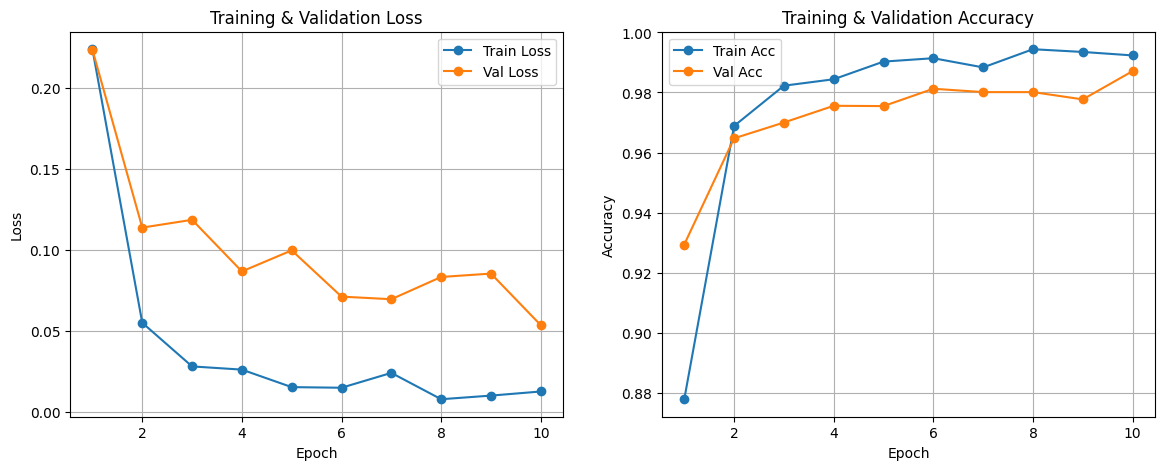

In [33]:
# ----------------------------
# Plot Training Curves
# ----------------------------
epochs = range(1, NUM_EPOCHS + 1)
plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs, history['val_loss'], label='Val Loss', marker='o')
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, history['train_acc'], label='Train Acc', marker='o')
plt.plot(epochs, history['val_acc'], label='Val Acc', marker='o')
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

In [34]:
# ----------------------------
# Test Evaluation
# ----------------------------
teacher_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = teacher_model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = sum([p==l for p,l in zip(all_preds, all_labels)]) / len(all_labels)
print(f"Test Accuracy: {test_acc*100:.2f}%")

print("\n===== CLASSIFICATION REPORT (TEST SET) =====\n")
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes, digits=4))

Test Accuracy: 98.63%

===== CLASSIFICATION REPORT (TEST SET) =====

                        precision    recall  f1-score   support

        bacterial_spot     0.9863    0.9853    0.9858       952
          early_blight     0.9796    0.9758    0.9777      1032
               healthy     0.9813    0.9924    0.9869      1059
           late_blight     0.9867    0.9858    0.9863      1201
            leaf_miner     0.9392    0.8968    0.9175       155
             leaf_mold     0.9967    0.9890    0.9928       909
  magnesium_deficiency     0.9586    0.9858    0.9720       141
          mosaic_virus     0.9921    0.9974    0.9947       756
   nitrogen_deficiency     0.9153    0.9818    0.9474        55
  potassium_deficiency     1.0000    0.9167    0.9565        12
        powdery_mildew     0.9742    1.0000    0.9869       189
    septoria_leaf_spot     0.9802    0.9824    0.9813       909
          spider_mites     1.0000    0.9985    0.9993       678
    spotted_wilt_virus     0.8312 

In [35]:
from sklearn.metrics import confusion_matrix
teacher_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = teacher_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [36]:
cm = confusion_matrix(all_labels, all_preds)

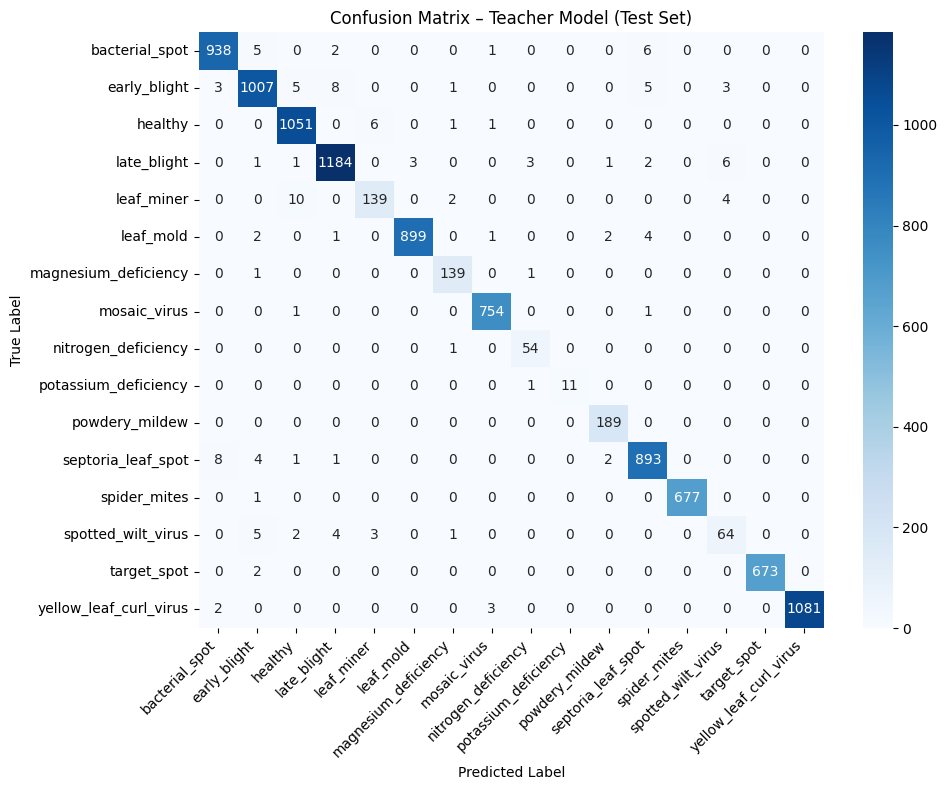

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = test_dataset.classes
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Teacher Model (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

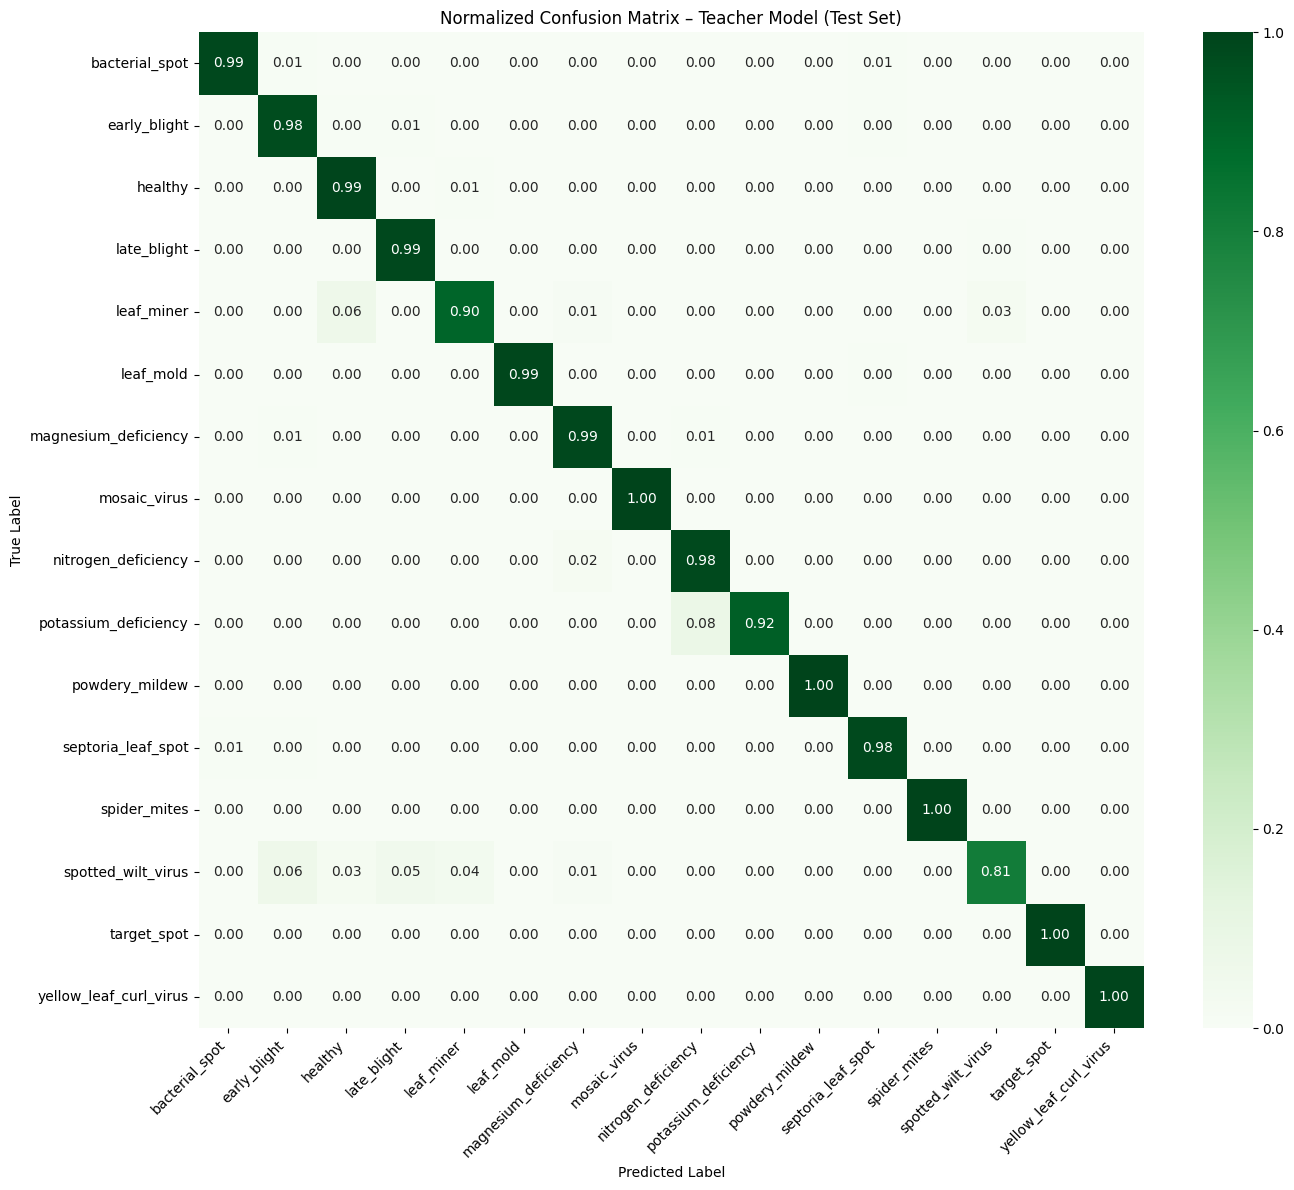

In [38]:
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix – Teacher Model (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [42]:
# Path where you uploaded client prototypes
CLIENT_PROTOTYPE_PATHS = [
    "/content/client1_prototypes.pt",
    "/content/client2_prototypes.pt"
]

client_prototypes = []
client_classes_list = []

for path in CLIENT_PROTOTYPE_PATHS:
    data = torch.load(path, weights_only=False)  # dictionary {class_name: embedding_vector}
    client_prototypes.append(data)
    client_classes_list.append(list(data.keys()))

print("Loaded client prototypes:", [len(p) for p in client_prototypes])


Loaded client prototypes: [4, 10]


In [43]:
def normalize_class_name(name):
    return name.strip().lower().replace(" ", "_")

normalized_prototypes = []
for proto_dict in client_prototypes:
    norm_dict = {normalize_class_name(k): v for k, v in proto_dict.items()}
    normalized_prototypes.append(norm_dict)

In [45]:
from itertools import chain

global_classes = sorted(list(set(chain.from_iterable([d.keys() for d in normalized_prototypes]))))
print("Global classes:", global_classes)

Global classes: ['tomato___bacterial_spot', 'tomato___early_blight', 'tomato___healthy', 'tomato___late_blight', 'tomato___leaf_mold', 'tomato___septoria_leaf_spot', 'tomato___spider_mites_two-spotted_spider_mite', 'tomato___target_spot', 'tomato___tomato_mosaic_virus', 'tomato___tomato_yellow_leaf_curl_virus']


In [48]:
global_prototypes = {}

# Aggregate embeddings
for cls in global_classes:
    embeddings = []
    for proto_dict in normalized_prototypes:
        if cls in proto_dict:
            # Convert numpy array to torch tensor
            emb = torch.tensor(proto_dict[cls], dtype=torch.float32)
            embeddings.append(emb.unsqueeze(0))  # Add batch dimension
    if embeddings:
        aggregated = torch.cat(embeddings, dim=0).mean(dim=0)  # mean of all client embeddings
        global_prototypes[cls] = aggregated

print("Aggregated global prototypes ready for KD.")

Aggregated global prototypes ready for KD.


In [49]:
import torch
import torch.nn.functional as F

# teacher_model must be loaded and in eval mode
teacher_model.eval()

# Extract teacher logits for a given embedding
def teacher_soft_labels_from_prototypes(global_prototypes, teacher_model, temp=1.0):
    """
    global_prototypes: dict {class_name: embedding_tensor}
    teacher_model: trained teacher model
    temp: temperature for soft labels
    """
    soft_labels = {}

    for cls, emb in global_prototypes.items():
        # Make batch-like tensor
        emb = emb.unsqueeze(0).to(device)  # shape: [1, feature_dim]

        # Forward pass through teacher classifier
        with torch.no_grad():
            # If your teacher model has a classifier after feature extractor
            # you can pass embeddings through classifier
            # Otherwise, if you have only full model, you may need to generate pseudo-images
            logits = teacher_model(emb)  # shape: [1, num_classes]
            probs = F.softmax(logits / temp, dim=1)  # temperature scaling

        soft_labels[cls] = probs.squeeze(0).cpu()  # store as 1D tensor

    return soft_labels

In [51]:
teacher_model.eval()
teacher_model = teacher_model.to(device)

# Remove the classifier, keep feature extractor
teacher_feature_extractor = nn.Sequential(*list(teacher_model.children())[:-1])
teacher_feature_extractor.eval()
teacher_feature_extractor.to(device)

Sequential(
  (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (2): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d

In [52]:
import numpy as np

# normalized_prototypes: list of dicts per client, {class_name: embedding (np.array)}
global_prototypes = {}  # aggregated per class

for proto_dict in normalized_prototypes:
    for cls, emb in proto_dict.items():
        emb_tensor = torch.tensor(emb, dtype=torch.float).to(device)
        if cls in global_prototypes:
            global_prototypes[cls].append(emb_tensor.unsqueeze(0))
        else:
            global_prototypes[cls] = [emb_tensor.unsqueeze(0)]

# Average embeddings per class (aggregate)
for cls in global_prototypes:
    global_prototypes[cls] = torch.cat(global_prototypes[cls], dim=0).mean(dim=0)  # [embedding_dim]


In [53]:
# Normalize prototypes to get “soft labels” in embedding space
teacher_soft_labels = {}
for cls, emb in global_prototypes.items():
    teacher_soft_labels[cls] = F.normalize(emb, dim=0)  # unit vector


In [54]:
teacher_soft_labels_cpu = {cls: emb.cpu().numpy() for cls, emb in teacher_soft_labels.items()}


In [55]:
torch.save(teacher_soft_labels_cpu, "/content/teacher_soft_labels.pt")
print("Teacher soft labels saved as teacher_soft_labels.pt")


Teacher soft labels saved as teacher_soft_labels.pt
